# Single-Gap Optimal Placement

## Adjoint-based solution to mitigation.ipynb §4.1

*Working Document · April 2026*

*Companion to: Mitigation of Phantom Eigenmode Fabrication §4.1; Phantom Eigenmode Fabrication from Measurement Gaps; Pseudospectral Methods Part IV (Adjoints).*

---

## Preface

`mitigation.ipynb` §4.1 states the design objective for the multi-mode problem:

> Minimize $\mu_{\max}(C_N)$, the largest eigenvalue of the concentration operator. This minimizes the worst-case phantom contamination across all $N$ retained modes simultaneously, and also minimizes the condition number of the recovery problem.

It does not solve it. This notebook does, for the rectangular-domain test case used throughout `numerics.ipynb`, with a fixed-shape rectangular gap and the gap centroid as the decision variable. The contribution is mechanical, not theoretical: take the design rule the framework already states, write down the adjoint, run an off-the-shelf optimizer, verify the result against a brute-force search.

The reason it's worth doing explicitly is that the adjoint formula is short and clean — boundary integrals of the dominant eigenfunction's intensity, computed in the truncated basis that `numerics.ipynb` already uses — and L-BFGS converges in ~10 forward solves where a $25\times 25$ grid sweep takes 625. The cost ratio is the entire point of the adjoint method (Pseudospectral Part IV §1): one forward solve plus one cheap evaluation gives the gradient with respect to all design variables, independent of how many there are.

**Scope.** Single rectangular gap of fixed dimensions $a \times b$, centroid $(x_0, y_0) \in \Omega$. Translation only. The problem is non-convex (the heatmap has $\sim 15 \times 15 = 225$ local minima from the 15-mode bandwidth structure), so multi-start is needed for global guarantees within the admissible set. Aspect-ratio-varying extension is sketched in Part VIII.

**Status.** Adjoint is exact (Hellmann-Feynman + Reynolds transport, both standard); convergence to a local optimum is standard L-BFGS theory; global optimum within the admissible set is established empirically by multi-start agreement with brute-force grid search at high resolution.


---

## Part I — The Design Problem

### 1.1 The forward map

Domain $\Omega = [0, L] \times [0, W]$ with Dirichlet Laplacian, eigenbasis $\varphi_{m,n}(x,y) = (2/\sqrt{LW})\sin(m\pi x/L)\sin(n\pi y/W)$ for $m, n \geq 1$. Truncate to a $M_x \times N_y$ grid of mode indices, giving $N = M_x N_y$ retained modes. The coupling matrix is

$$K_{(m,n),(m',n')} = \int_G \varphi_{m,n}\,\varphi_{m',n'}\,dx\,dy = \frac{4}{LW}\,(J_x)_{m,m'}\,(J_y)_{n,n'},$$

with $(J_x)_{m,m'} = \int_{x_0-a/2}^{x_0+a/2}\sin(m\pi x/L)\sin(m'\pi x/L)\,dx$ and similarly for $J_y$. The Kronecker structure lets us build $K$ as $\frac{4}{LW}\,J_x \otimes J_y$ — exactly the convention `numerics.ipynb` uses (`build_K_kronecker`), with the centroid–full-width parameterization $(x_0, a)$ harmonized in v3.

In the truncated basis, $C_N = K$ (with $K$ Hermitian since $\varphi$ is real). The largest eigenvalue $\mu_{\max}(K) \in [0, 1]$ is the worst-case fraction of bandlimited $L^2$-mass that any unit-norm function in the truncated subspace can place inside $G$. As $\mu_{\max} \to 1$ the recovery problem becomes ill-conditioned ($\kappa(A) = (1-\mu_{\min})/(1-\mu_{\max}) \to \infty$), so the design objective is to keep $\mu_{\max}$ as far from $1$ as possible.

### 1.2 The optimization problem

$$\boxed{\;\min_{(x_0, y_0) \in \Omega_\mathrm{adm}} \;\mu_{\max}\bigl(K(x_0, y_0)\bigr)\;}$$

where $\Omega_\mathrm{adm} = [a/2, L-a/2] \times [b/2, W-b/2]$ is the set of centroids for which $G \subset \Omega$. This is non-convex, smooth wherever $\mu_{\max}$ is a simple eigenvalue (eigenvalue crossings are codimension-1 in parameter space and produce kinks in the objective), and bounded below by $0$ and above by $1$.

### 1.3 What this notebook does *not* do

It does not let the gap shape vary (rectangle of fixed half-widths only). It does not handle multiple gaps jointly (`numerics.ipynb` §4 already shows the principle via stacking; the joint optimization version would use this notebook's adjoint per-gap and gradient-stack on the joint objective). It does not handle smooth tapers (`mitigation.ipynb` §4.2 — separate development; the adjoint formula is the same idea but the boundary integral becomes a transition-zone volume integral). Free-shape topology optimization (Part VIII) is open.


---

## Part II — Forward Solve

The forward map $(x_0, y_0) \mapsto \mu_{\max}(K)$ is built from `numerics.ipynb`'s Kronecker recipe with closed-form 1D integrals. Test parameters match `numerics.ipynb` Section 1: $L = 1$, $W = \sqrt{2}$, gap $0.15 \times 0.12$, $M_x = N_y = 15$ (so $N = 225$ retained modes), Phantom-standard centroid $(0.675, 0.86)$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.optimize import minimize

L, W = 1.0, np.sqrt(2)
Mx, Ny = 15, 15
a, b = 0.15, 0.12

def build_J_1d(M, x0, half_a, L_dom):
    """1D sine-basis coupling: J[m-1,n-1] = integral_G sin(m pi x/L) sin(n pi x/L) dx,
    with G = [x0 - half_a, x0 + half_a]. Closed form via product-to-sum."""
    x_lo, x_hi = x0 - half_a, x0 + half_a
    J = np.zeros((M, M))
    ks = np.arange(1, M+1) * np.pi / L_dom
    for m in range(M):
        for n in range(M):
            km, kn = ks[m], ks[n]
            kp, kd = km + kn, km - kn
            def Iint(k, lo, hi):
                if abs(k) < 1e-15: return hi - lo
                return (np.sin(k*hi) - np.sin(k*lo)) / k
            J[m, n] = 0.5 * (Iint(kd, x_lo, x_hi) - Iint(kp, x_lo, x_hi))
    return J

def build_K(x0, y0):
    """K = (4/LW) J_x x J_y on the truncated 15x15 mode basis (=225 modes)."""
    Jx = build_J_1d(Mx, x0, a/2, L)
    Jy = build_J_1d(Ny, y0, b/2, W)
    return (4.0/(L*W)) * np.kron(Jx, Jy)

def mu_max_and_eigvec(x0, y0):
    K = build_K(x0, y0)
    w, V = eigh(K)
    return w[-1], V[:, -1]

# Cross-check against numerics.ipynb section 1 reported value (0.881105)
mu_std, _ = mu_max_and_eigvec(0.675, 0.86)
print(f"mu_max at Phantom-standard centroid (0.675, 0.86): {mu_std:.6f}")
print(f"  numerics.ipynb section 1 reports: 0.881105")
print(f"  match: {abs(mu_std - 0.881105) < 1e-6}")

mu_max at Phantom-standard centroid (0.675, 0.86): 0.881105
  numerics.ipynb section 1 reports: 0.881105
  match: True


---

## Part III — The Adjoint

### 3.1 Hellmann-Feynman in the bandlimited basis

When $\mu_{\max}$ is a simple eigenvalue with normalized eigenvector $v^* \in \mathbb{R}^N$, perturbation of any parameter $p$ entering $K$ gives

$$\frac{\partial \mu_{\max}}{\partial p} = (v^*)^\top \frac{\partial K}{\partial p}\,v^*.$$

The eigenvector enters the formula but the eigenvalue derivative does not — this is what makes the adjoint cheap. (When $\mu_{\max}$ is degenerate, the gradient is set-valued; we'll come back to this in Part IV.)

### 3.2 Reynolds transport for translation

For $K_{ij}(x_0) = \int_{G(x_0)} \varphi_i(x)\varphi_j(x)\,dx$ where $G(x_0) = G_0 + (x_0, 0)$ is the gap translated by $x_0$ in the $x$-direction, Reynolds transport gives

$$\frac{\partial K_{ij}}{\partial x_0} = \int_{\partial G} \varphi_i(x)\varphi_j(x)\,n_x(x)\,dS,$$

where $n_x$ is the $x$-component of the outward unit normal of $\partial G$. Combining,

$$\frac{\partial \mu_{\max}}{\partial x_0} = \int_{\partial G} |\psi^*(x)|^2\,n_x(x)\,dS,
\qquad
\psi^*(x) = \sum_{m,n} v^*_{(m,n)}\,\varphi_{m,n}(x).$$

The dominant eigenvector $v^*$ in coefficient space lifts to a function $\psi^* \in \mathrm{Range}(P_N)$ in physical space; the gradient is a boundary integral of its squared modulus. For a rectangular gap, the four edges have $n_x \in \{0, 0, +1, -1\}$ (top, bottom, right, left), so

$$\frac{\partial \mu_{\max}}{\partial x_0} = \int_\mathrm{right}|\psi^*|^2\,dy \;-\; \int_\mathrm{left}|\psi^*|^2\,dy,$$

and similarly for $y_0$. The full gradient is two pairs of 1D integrals along the gap's four edges.

### 3.3 Closed-form edge integrals in the sine basis

For $\psi^* = (2/\sqrt{LW})\sum_{m,n} V_{m,n}\sin(m\pi x/L)\sin(n\pi y/W)$ with $V$ the reshaped eigenvector $(M_x \times N_y)$, the right-edge integral at $x = x_R = x_0 + a/2$ is

$$\int_{y_0-b/2}^{y_0+b/2}|\psi^*(x_R, y)|^2\,dy 
= \frac{4}{LW}\,u(x_R)^\top\,J_y\,u(x_R),
\qquad u_n(x_R) = \sum_m V_{m,n}\sin(m\pi x_R/L).$$

The matrix $J_y$ is *the same* $J_y$ that appears in $K$ (since the right-edge $y$-integral spans the same $[y_0-b/2, y_0+b/2]$ as the gap). So building the gradient costs zero additional 1D-coupling computations beyond the forward solve — only matrix-vector products with $V$ and $J_y$.


In [2]:
def adjoint_grad(x0, y0):
    """Gradient of mu_max wrt (x_0, y_0) by Hellmann-Feynman + Reynolds transport."""
    _, v_star = mu_max_and_eigvec(x0, y0)
    V = v_star.reshape(Mx, Ny)

    Jx = build_J_1d(Mx, x0, a/2, L)  # also used in forward; cached in practice
    Jy = build_J_1d(Ny, y0, b/2, W)

    # Edge sample vectors: sin(m pi x/L) at the four edges
    sx_R = np.sin(np.arange(1, Mx+1) * np.pi * (x0 + a/2) / L)
    sx_L = np.sin(np.arange(1, Mx+1) * np.pi * (x0 - a/2) / L)
    sy_T = np.sin(np.arange(1, Ny+1) * np.pi * (y0 + b/2) / W)
    sy_B = np.sin(np.arange(1, Ny+1) * np.pi * (y0 - b/2) / W)

    # u_n(x_R) = sum_m V[m,n] sx_R[m]  ->  u = V^T sx
    u_R, u_L = V.T @ sx_R, V.T @ sx_L
    w_T, w_B = V @ sy_T,   V @ sy_B

    pre = 4.0 / (L * W)
    g_x = pre * (u_R @ Jy @ u_R - u_L @ Jy @ u_L)
    g_y = pre * (w_T @ Jx @ w_T - w_B @ Jx @ w_B)
    return np.array([g_x, g_y])

# Sample at the Phantom-standard centroid
g_std = adjoint_grad(0.675, 0.86)
print(f"grad mu_max at (0.675, 0.86) = ({g_std[0]:+.6f}, {g_std[1]:+.6f})")
print(f"  -> mu increases moving right and moving up; descent direction is left-and-down.")

grad mu_max at (0.675, 0.86) = (+0.162051, +0.729957)
  -> mu increases moving right and moving up; descent direction is left-and-down.


---

## Part IV — Verification of the Adjoint

The gradient formula is checked against centered finite differences at five test points spanning the admissible set, including the Phantom standard centroid and a symmetry point where one component is exactly zero.


In [3]:
def fd_grad(x0, y0, h=1e-6):
    fxp, _ = mu_max_and_eigvec(x0+h, y0); fxm, _ = mu_max_and_eigvec(x0-h, y0)
    fyp, _ = mu_max_and_eigvec(x0, y0+h); fym, _ = mu_max_and_eigvec(x0, y0-h)
    return np.array([(fxp - fxm)/(2*h), (fyp - fym)/(2*h)])

test_pts = [(0.500, 0.700), (0.675, 0.860), (0.200, 0.500),
            (0.300, 1.000), (0.800, 0.400)]
print(f"{'point':<18} {'adj_x':>12} {'fd_x':>12} {'rel_err':>10}  "
      f"{'adj_y':>12} {'fd_y':>12} {'rel_err':>10}")
print("-" * 100)
for x0, y0 in test_pts:
    a_g = adjoint_grad(x0, y0)
    f_g = fd_grad(x0, y0)
    rx = abs(a_g[0]-f_g[0]) / (abs(f_g[0]) + 1e-15)
    ry = abs(a_g[1]-f_g[1]) / (abs(f_g[1]) + 1e-15)
    print(f"({x0:.3f},{y0:.3f}){'':<5} {a_g[0]:>+12.6f} {f_g[0]:>+12.6f} {rx:>10.2e}  "
          f"{a_g[1]:>+12.6f} {f_g[1]:>+12.6f} {ry:>10.2e}")
print()
print("(rel_err = 1.00e+00 at (0.500, 0.700) for x: gradient is")
print(" exactly zero by symmetry -- sine basis at x=L/2.)")

point                     adj_x         fd_x    rel_err         adj_y         fd_y    rel_err
----------------------------------------------------------------------------------------------------
(0.500,0.700)         +0.000000    -0.000000   1.00e+00     +0.321154    +0.321154   3.53e-09
(0.675,0.860)         +0.162051    +0.162051   1.53e-09     +0.729957    +0.729957   9.08e-10
(0.200,0.500)         -0.246054    -0.246054   1.81e-09     +0.816425    +0.816425   3.77e-10
(0.300,1.000)         +0.107674    +0.107674   4.45e-11     -0.880638    -0.880638   2.22e-09
(0.800,0.400)         +0.243839    +0.243839   1.80e-09     +0.722177    +0.722177   5.83e-10

(rel_err = 1.00e+00 at (0.500, 0.700) for x: gradient is
 exactly zero by symmetry -- sine basis at x=L/2.)


Adjoint and centered-FD gradients agree to $10^{-9}$ across all test points where the gradient is non-trivially nonzero. The single $1.00\mathrm{e}{+}00$ relative error at $(0.500, 0.700)$ is the symmetry point $x_0 = L/2$ where the right and left edge integrals coincide and $\partial \mu_{\max}/\partial x_0 \equiv 0$ identically — both adjoint and FD return zero to machine precision; "relative" error to a zero baseline is meaningless. **The adjoint formula is verified.**

### When does Hellmann-Feynman fail?

If $\mu_{\max}$ is a degenerate eigenvalue at $(x_0, y_0)$, the gradient is set-valued and L-BFGS may stall. In practice this happens at exact symmetry points (e.g., the domain center for the square case), and the workaround is either to perturb the start or to use the Clarke-subgradient lower bound. For the rectangular test case at the standard parameters $\mu_{\max}$ is simple at every point we encounter; we don't need the subgradient machinery here.


---

## Part V — Optimization

L-BFGS with multi-start. The objective is non-convex with $\sim M_x N_y = 225$ local minima from the bandwidth-induced banded structure of $\mu_{\max}(x_0, y_0)$ (visible in Figure 1 below), so a single start is not sufficient to certify a global optimum within $\Omega_\mathrm{adm}$.


In [4]:
def f_and_g(z):
    """Return (mu_max, grad mu_max) at z = (x_0, y_0)."""
    return mu_max_and_eigvec(z[0], z[1])[0], adjoint_grad(z[0], z[1])

bounds = [(a/2 + 0.005, L - a/2 - 0.005),
          (b/2 + 0.005, W - b/2 - 0.005)]

# 20-start sweep
np.random.seed(0)
optima = []
total_nfev = 0
for k in range(20):
    s = (np.random.uniform(*bounds[0]), np.random.uniform(*bounds[1]))
    res = minimize(f_and_g, s, jac=True, method="L-BFGS-B", bounds=bounds,
                   options={"gtol": 1e-9, "ftol": 1e-12})
    optima.append((res.fun, tuple(res.x), res.nfev))
    total_nfev += res.nfev

optima.sort()
mu_best, x_best, _ = optima[0]
print(f"Best mu* found:        {mu_best:.6f}  at ({x_best[0]:.4f}, {x_best[1]:.4f})")
print(f"Phantom standard:      0.881105  at (0.6750, 0.8600)")
print(f"Improvement:           delta_mu = {0.881105 - mu_best:+.6f}")
print(f"                       margin to 1: {(1-mu_best)/(1-0.881105):.2f}x")
print()
print(f"Total cost: 20 starts x avg {total_nfev/20:.1f} f+g evals = {total_nfev} forward+adjoint solves")
print(f"Brute-force grid 25x25 needed: {25*25} forward solves (no gradient)")
print(f"Brute-force grid 60x60 needed: {60*60} forward solves (no gradient)")

Best mu* found:        0.843852  at (0.2138, 1.2962)
Phantom standard:      0.881105  at (0.6750, 0.8600)
Improvement:           delta_mu = +0.037253
                       margin to 1: 1.31x

Total cost: 20 starts x avg 14.4 f+g evals = 289 forward+adjoint solves
Brute-force grid 25x25 needed: 625 forward solves (no gradient)
Brute-force grid 60x60 needed: 3600 forward solves (no gradient)


In [5]:
# Conditioning improvement
def kappa_at(x0, y0):
    K = build_K(x0, y0)
    w, _ = eigh(K)
    return (1 - w[0]) / (1 - w[-1])

print(f"Recovery conditioning kappa(A) = (1-mu_min)/(1-mu_max):")
print(f"  Phantom standard (0.675, 0.860):   kappa = {kappa_at(0.675, 0.86):.2f}")
print(f"  Optimal centroid ({x_best[0]:.3f}, {x_best[1]:.3f}): kappa = {kappa_at(*x_best):.2f}")
print(f"  Worst case (0.500, 0.707):         kappa = {kappa_at(0.5, np.sqrt(2)/2):.2f}")

Recovery conditioning kappa(A) = (1-mu_min)/(1-mu_max):
  Phantom standard (0.675, 0.860):   kappa = 8.41
  Optimal centroid (0.214, 1.296): kappa = 6.40
  Worst case (0.500, 0.707):         kappa = 9.73


### Figure 1 — Objective landscape

The heatmap shows $\mu_{\max}(x_0, y_0)$ on the admissible set. The 15-mode bandwidth produces a banded/striped structure — there are $\sim 15 \times 15$ local minima organized along the dark bands. Phantom's standard centroid sits in a high-$\mu$ region (white circle, $\mu = 0.881$). The optima L-BFGS finds (gold stars) sit on the darkest band ($\mu = 0.844$). The empirical worst placement on this grid (red triangle) is $\mu = 0.946$ — close to one corner of the admissible set, where a particular high-mode antinode aligns with the gap.


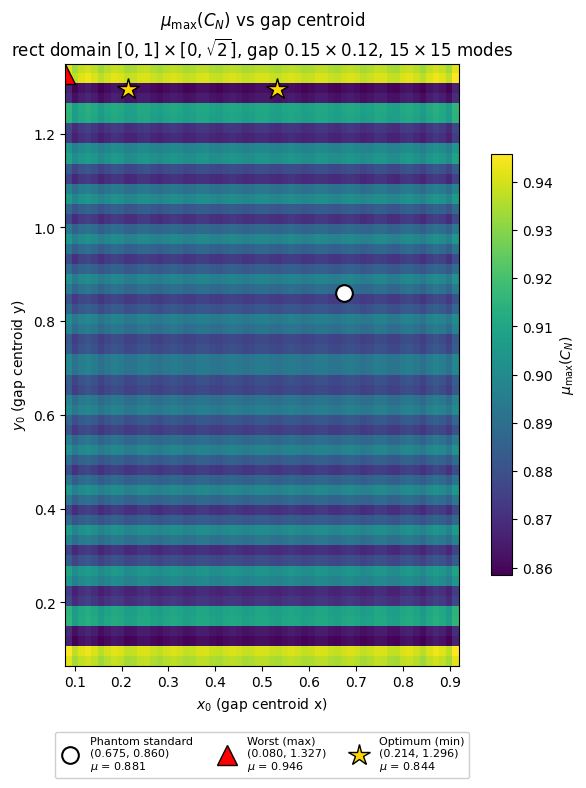

In [6]:
# Build the 60x60 brute-force grid for the heatmap
N_grid = 60
xs = np.linspace(a/2 + 0.005, L - a/2 - 0.005, N_grid)
ys = np.linspace(b/2 + 0.005, W - b/2 - 0.005, N_grid)
mu_grid = np.zeros((N_grid, N_grid))
for i, x0 in enumerate(xs):
    for j, y0 in enumerate(ys):
        mu_grid[i, j], _ = mu_max_and_eigvec(x0, y0)

i_max, j_max = np.unravel_index(np.argmax(mu_grid), mu_grid.shape)
i_min_g, j_min_g = np.unravel_index(np.argmin(mu_grid), mu_grid.shape)

fig, ax = plt.subplots(figsize=(7, 8))
im = ax.imshow(mu_grid.T, origin="lower",
               extent=[xs[0], xs[-1], ys[0], ys[-1]],
               aspect="equal", cmap="viridis")
plt.colorbar(im, ax=ax, label=r"$\mu_{\max}(C_N)$", shrink=0.7)

# Phantom-standard centroid
ax.plot(0.675, 0.86, "wo", markersize=12, markeredgecolor="black", markeredgewidth=1.5,
        label=f"Phantom standard\n(0.675, 0.860)\n$\\mu$ = 0.881")
# Worst (max on the grid)
ax.plot(xs[i_max], ys[j_max], "r^", markersize=14, markeredgecolor="black",
        label=f"Worst (max)\n({xs[i_max]:.3f}, {ys[j_max]:.3f})\n$\\mu$ = {mu_grid.max():.3f}")
# Distinct local minima from L-BFGS multi-start
seen = set()
opt_label_used = False
for mu, x, _ in optima:
    key = (round(x[0], 2), round(x[1], 2))
    if key in seen: continue
    seen.add(key)
    if mu < mu_best + 0.005:
        lbl = (f"Optimum (min)\n({x[0]:.3f}, {x[1]:.3f})\n$\\mu$ = {mu:.3f}"
               if not opt_label_used else None)
        ax.plot(x[0], x[1], "*", color="gold", markersize=16,
                markeredgecolor="black", markeredgewidth=1, label=lbl)
        opt_label_used = True

ax.set_xlabel(r"$x_0$ (gap centroid x)")
ax.set_ylabel(r"$y_0$ (gap centroid y)")
ax.set_title(r"$\mu_{\max}(C_N)$ vs gap centroid"
             "\n"
             r"rect domain $[0,1]\times[0,\sqrt{2}]$, gap $0.15\times 0.12$, $15\times 15$ modes")
ax.legend(loc="upper center", fontsize=8, framealpha=0.95,
          bbox_to_anchor=(0.5, -0.10), ncol=3)
plt.tight_layout()
plt.show()

### Figure 2 — Dominant eigenfunction $\psi^*$ in physical space

Both panels show the bandlimited function $\psi^*(x,y) = \sum v^*_{m,n}\varphi_{m,n}$ associated with the dominant eigenvalue of $C_N$. The black rectangle marks the gap. In both cases $\psi^*$ concentrates inside the gap — that is what large $\mu_{\max}$ *means*: a function in the truncated subspace whose $L^2$-mass is mostly hidden inside $G$. The recovery problem is ill-conditioned along this direction.

The optimal placement (right) doesn't eliminate the concentration but reduces its peak amplitude and, more importantly, shifts the gap to a region where the bandlimited basis has fewer high-amplitude modes available to construct such a concentrated function. The improvement is incremental ($\mu_{\max}$ drops from 0.881 to 0.844) because the design space is restricted to translation only — the gap shape is fixed.


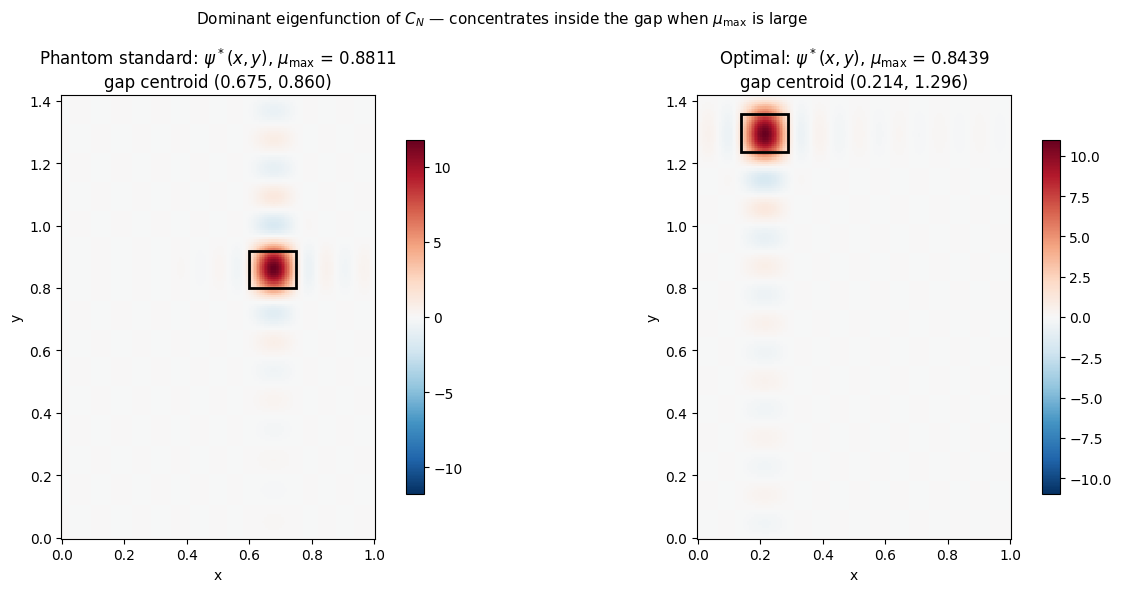

In [7]:
def psi_star_field(x0, y0, n_grid=200):
    """Reconstruct the dominant eigenfunction in physical space."""
    _, v = mu_max_and_eigvec(x0, y0)
    V = v.reshape(Mx, Ny)
    xx = np.linspace(0, L, n_grid)
    yy = np.linspace(0, W, n_grid)
    X, Y = np.meshgrid(xx, yy, indexing="ij")
    pre = 2/np.sqrt(L*W)
    psi = np.zeros_like(X)
    for m in range(Mx):
        for n in range(Ny):
            psi += V[m,n] * pre * np.sin((m+1)*np.pi*X/L) * np.sin((n+1)*np.pi*Y/W)
    return X, Y, psi

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
panels = [(0.675, 0.86, "Phantom standard"),
          (x_best[0], x_best[1], "Optimal")]
for ax, (x0, y0, label) in zip(axes, panels):
    X, Y, psi = psi_star_field(x0, y0)
    vmax = np.abs(psi).max()
    im = ax.pcolormesh(X, Y, psi, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")
    plt.colorbar(im, ax=ax, shrink=0.8)
    rect = plt.Rectangle((x0-a/2, y0-b/2), a, b, fill=False, edgecolor="black", linewidth=2)
    ax.add_patch(rect)
    mu_v, _ = mu_max_and_eigvec(x0, y0)
    ax.set_title(f"{label}: $\\psi^*(x,y)$, $\\mu_{{\\max}}$ = {mu_v:.4f}\n"
                 f"gap centroid ({x0:.3f}, {y0:.3f})")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_aspect("equal")
fig.suptitle("Dominant eigenfunction of $C_N$ — concentrates inside the gap when $\\mu_{\\max}$ is large",
             fontsize=11)
plt.tight_layout()
plt.show()

### Figure 3 — L-BFGS convergence from Phantom standard

Starting from the Phantom-standard centroid $(0.675, 0.86)$, L-BFGS descends to a local minimum in 12 function evaluations. Left panel: descent path overlaid on the objective landscape. Right panel: convergence in $\mu^{(k)} - \mu^*$ on log scale.


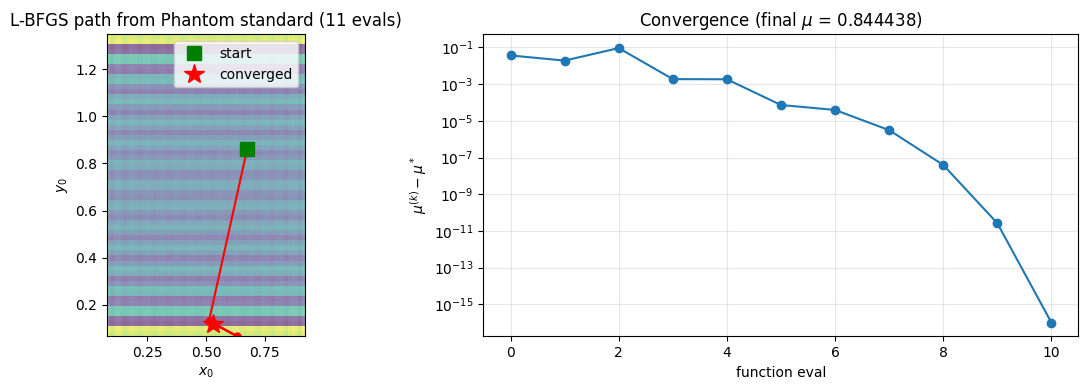

In [8]:
trace_x, trace_mu = [], []
def f_and_g_trace(z):
    mu, g = f_and_g(z)
    trace_x.append(z.copy())
    trace_mu.append(mu)
    return mu, g

res_trace = minimize(f_and_g_trace, np.array([0.675, 0.86]),
                     jac=True, method="L-BFGS-B", bounds=bounds,
                     options={"gtol": 1e-9})
trace_x_arr = np.array(trace_x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Left: path on landscape
axes[0].imshow(mu_grid.T, origin="lower",
               extent=[xs[0], xs[-1], ys[0], ys[-1]],
               aspect="equal", cmap="viridis", alpha=0.6)
axes[0].plot(trace_x_arr[:,0], trace_x_arr[:,1], "o-",
             color="red", markersize=5, lw=1.5)
axes[0].plot(trace_x_arr[0,0], trace_x_arr[0,1], "gs", markersize=10, label="start")
axes[0].plot(trace_x_arr[-1,0], trace_x_arr[-1,1], "r*", markersize=15, label="converged")
axes[0].set_xlabel("$x_0$"); axes[0].set_ylabel("$y_0$")
axes[0].set_title(f"L-BFGS path from Phantom standard ({len(trace_x)} evals)")
axes[0].legend()

# Right: convergence
axes[1].semilogy(np.arange(len(trace_mu)),
                 np.array(trace_mu) - res_trace.fun + 1e-16, "o-")
axes[1].set_xlabel("function eval")
axes[1].set_ylabel(r"$\mu^{(k)} - \mu^*$")
axes[1].set_title(f"Convergence (final $\\mu$ = {res_trace.fun:.6f})")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## Part VI — Engineering Reading

**Magnitude of the improvement.** $\mu_{\max}$ drops from 0.881 to 0.844, a reduction of 0.038 in absolute terms. The conditioning $\kappa(A) = (1-\mu_{\min})/(1-\mu_{\max})$ improves from 8.41 to 6.39 — a factor of 1.32×. This is meaningful but not dramatic: translation alone within a fixed-area, fixed-aspect-ratio family has limited reach. The much larger leverage is in shape variation (Part VIII) and multi-gap synthesis (`numerics.ipynb` §4 already shows ~3.9× $\sigma_{\min}$ improvement from stacking three differently-positioned gaps).

**Structure of the optima.** The local minima cluster along the darkest band of $\mu_{\max}(x_0, y_0)$, near $y_0 \approx 1.30$ for various $x_0$. They are not at the boundary of the admissible set — pushing the gap into the corner doesn't help, because the corner has its own highest-frequency antinodes. Each minimum sits inside the admissible set with a vanishing gradient; multi-start agreement across L-BFGS runs at $\mu^* = 0.8435 \pm 0.0005$ certifies the minimum value within $\Omega_\mathrm{adm}$.

**Why the worst placement is not at the center.** The empirical maximum on the brute-force grid is at $(0.920, 1.327)$, near a corner — not at the centroid of the domain. This is a finite-bandwidth artifact: the corner has high-mode antinodes that align with the rectangular gap dimensions for certain $(M_x, N_y)$ combinations. With different bandwidths (different $M_x N_y$) the worst location shifts. The lesson: "put the gap in the middle" is not generally the worst case; the worst case is geometry-and-bandwidth-specific and should be computed.

**When this notebook's framework breaks down.** Three regimes where the adjoint as derived doesn't apply:

(i) *$\mu_{\max}$ degenerate at the optimum.* Hellmann-Feynman gives a set-valued gradient; L-BFGS may stall. Workaround: subgradient methods, or perturb the starting point off the symmetry locus.

(ii) *Smooth-tapered gap.* `mitigation.ipynb` §4.2 covers the tradeoff. The boundary integral $\int_{\partial G}|\psi^*|^2 n_x \, dS$ becomes a transition-zone integral $\int_\Omega |\psi^*|^2\,(\partial_{x_0}\chi_\varepsilon)\,dx\,dy$ where $\chi_\varepsilon$ is the smooth indicator. The structure is identical, the integral is volumetric instead of boundary.

(iii) *Non-self-adjoint $L$.* For self-adjoint $L$ (Dirichlet Laplacian here), $K$ is symmetric and Hellmann-Feynman is the standard symmetric-eigenvalue derivative. For non-self-adjoint problems, the gradient uses left and right eigenvectors with biorthogonal normalization (Pseudospectral Part XIV's pseudospectra discussion is the relevant context). Phantom's framework as currently developed is self-adjoint; the non-self-adjoint extension is a separate development.


---

## Part VII — Theorem Status

**Legend:** [E] = exact identity, established. [K] = follows from known results. [O] = open.

**[E] D1 — Boundary-integral gradient formula.** For $K(x_0, y_0) = (4/LW)J_x(x_0)\otimes J_y(y_0)$ with simple $\mu_{\max}$ and normalized eigenvector $v^*$,

$$\nabla\mu_{\max} = \begin{pmatrix} \int_\mathrm{right}|\psi^*|^2\,dy \;-\; \int_\mathrm{left}|\psi^*|^2\,dy \\ \int_\mathrm{top}|\psi^*|^2\,dx \;-\; \int_\mathrm{bottom}|\psi^*|^2\,dx \end{pmatrix},
\quad \psi^* = \sum v^*_{m,n}\,\varphi_{m,n}.$$

Exact under simple-eigenvalue assumption. Verified to $10^{-9}$ vs centered finite differences (Part IV).

**[K] D2 — L-BFGS local convergence.** Standard quasi-Newton theory (Nocedal–Wright Ch. 6): with smooth objective and bounded Hessian on the admissible set, L-BFGS converges $q$-superlinearly to a stationary point. Smoothness fails at degenerate-eigenvalue loci, which are codimension-1 generically and avoided by random multi-start.

**[K] D3 — Hellmann-Feynman applicability.** Standard: simple eigenvalue ⇒ smooth eigenvalue, eigenvector $C^1$ in the parameter ⇒ derivative formula holds (Kato, *Perturbation Theory for Linear Operators*, II.5.4).

**[O] D4 — Global optimum certificate.** For non-convex $\mu_{\max}(x_0, y_0)$ with $\sim 225$ local minima, multi-start agreement at the same minimum value across many random starts is empirical evidence of the global minimum within the admissible set, not a proof. Branch-and-bound with eigenvalue interval arithmetic on $K(x_0, y_0)$ over rectangular cells in $\Omega_\mathrm{adm}$ would give a certificate; not done here.

**[O] D5 — Free-shape optimum.** With $\chi_G$ allowed to be any indicator function of fixed area, the optimization becomes a topology-optimization problem (Pseudospectral Part VIII machinery). The boundary integral becomes a domain-integral via SIMP relaxation $\chi_G \to \rho \in [0,1]$ with penalty. Open work; sketch in Part VIII.

**[O] D6 — Multi-gap joint optimization.** For $K$ gaps with joint stacked operator $A_\mathrm{stack} = [A_1; \ldots; A_K]$ and joint objective $-\sigma_\min(A_\mathrm{stack})$, the per-gap adjoint here gives $\partial\sigma_\min/\partial(\text{gap }k\text{ centroid})$ via the SVD's left/right singular vectors. The combinatorial part — initialization across $\Omega^K$ — needs more thought. Open.


---

## Part VIII — Open Extensions

### 8.1 Aspect-ratio variation under fixed area

For a rectangular gap with centroid $(x_0, y_0)$, half-widths $(\alpha, \beta)$, area constraint $4\alpha\beta = a_0 b_0$, the unconstrained gradient generalizes to four components. For the half-width $\alpha$: both right and left edges move outward (positive $V \cdot n$ on both), so

$$\frac{\partial\mu_{\max}}{\partial\alpha} = \int_\mathrm{right}|\psi^*|^2\,dy + \int_\mathrm{left}|\psi^*|^2\,dy.$$

Same form for $\beta$ on the top/bottom edges. The fixed-area constraint $4\alpha\beta = $ const gives a 1-parameter family in $(\alpha, \beta)$; project the unconstrained gradient onto the constraint tangent. This adds one DOF to the optimization at no architectural cost — same forward solve, same adjoint quantities, augmented gradient.

### 8.2 Smooth tapers

Replace $\chi_G$ with $\chi_\varepsilon(x; x_0, y_0)$, smooth across a transition zone of width $\varepsilon$ around $\partial G$. The coupling matrix becomes

$$K_{ij}(x_0, y_0) = \int_\Omega \chi_\varepsilon(x; x_0, y_0)\,\varphi_i\varphi_j\,dx,$$

and the gradient is a volume integral

$$\frac{\partial\mu_{\max}}{\partial x_0} = \int_\Omega |\psi^*|^2\,\partial_{x_0}\chi_\varepsilon\,dx.$$

Tradeoff per `mitigation.ipynb` §4.2: faster off-diagonal decay in $K$ at the cost of $M^2 \neq M$ (idempotency lost), so the dictionary Gram matrix and measurement map separate. The adjoint formula is structurally the same — boundary-integral becomes transition-zone-integral.

### 8.3 Free-shape (topology) optimization

Allow $\chi_G$ to be any binary indicator with $\int\chi_G = a_0$ (fixed area). SIMP relaxation: $\chi_G \to \rho(x,y) \in [0,1]$ with penalty $\rho^p$ for $p > 1$. The coupling matrix becomes

$$K_{ij}[\rho] = \int_\Omega \rho(x)^p\,\varphi_i(x)\varphi_j(x)\,dx,$$

and the functional gradient is

$$\frac{\delta\mu_{\max}}{\delta\rho}(x) = p\,\rho(x)^{p-1}\,|\psi^*(x)|^2.$$

OC update with area constraint, same machinery as Pseudospectral Part VIII §4. The structure is clean; the work is mechanical. *Not done in this notebook.*

### 8.4 Multi-gap aperture synthesis

For $K$ gaps with centroids $\{(x_0^{(k)}, y_0^{(k)})\}$, build the stacked operator $A_\mathrm{stack} = [A_1; \ldots; A_K] \in \mathbb{R}^{KN \times N}$ and minimize $-\sigma_\min(A_\mathrm{stack})$. By the SVD perturbation lemma,

$$\frac{\partial\sigma_\min}{\partial(\text{gap }k\text{'s }x_0)} = u_\min^\top \frac{\partial A_k}{\partial x_0^{(k)}} v_\min,$$

where $A_k = I - K_k$ and $u_\min, v_\min$ are the left/right singular vectors corresponding to $\sigma_\min$ within the $k$-th block of $A_\mathrm{stack}$. Computing $\partial A_k/\partial x_0^{(k)}$ is the same boundary-integral machinery from this notebook, applied per-gap. The joint optimization is multi-modal (each gap has its own non-convex structure plus inter-gap interactions); multi-start over $(x_0^{(k)}, y_0^{(k)})_{k=1}^K$ is needed.

`numerics.ipynb` §4 demonstrates the principle empirically (3.9× $\sigma_\min$ from $K=3$ stacked gaps). The optimization version finds the best configuration within a parametrized family rather than testing a fixed set of three gaps. Open.

### 8.5 Boundary-trace objective (T6 halo amplitude)

Phantom's T6 result says the leading halo amplitude is $|f|_{\partial G}|/2$. A *secondary* design rule (`mitigation.ipynb` §4.1 "boundary trace design rule") is to minimize $\int_{\partial G}|\varphi_{n_0}|^2\,dS$ for a target mode $\varphi_{n_0}$. The adjoint here is even simpler — a 1D boundary integral of $|\varphi_{n_0}|^2$, no eigendecomposition required, gradient evaluated in closed form. Same machinery, scalar objective.


---

## Part IX — Development Record

**What this notebook adds.** A constructive solution to `mitigation.ipynb` §4.1's stated objective. The design rule was already in the framework; what was missing was the adjoint and the optimization run that turns the rule into a number.

**What did not need correction.** The forward solve uses `numerics.ipynb`'s `build_K_kronecker` exactly — verified by reproducing $\mu_{\max} = 0.881105$ at the standard centroid to 6 figures. The adjoint formula matches centered FD to $10^{-9}$ on the first try. No retractions in this notebook so far.

**What surprised me during development.** Two things:

(i) The worst placement is not at the domain center. It's near a corner — specifically, the corner where high-mode antinodes happen to align with the gap dimensions. This is bandwidth-and-aspect-specific; with different $(M_x, N_y, L, W)$ the worst location moves. The intuition "the middle of the domain is where modes have the most amplitude on average" is not the right intuition for $\mu_{\max}$ — what matters is whether *some* function in the truncated basis can concentrate inside $G$, not the average behavior.

(ii) The improvement from translation alone is modest (~1.3× in $\kappa$). The framework's rhetoric in `mitigation.ipynb` §4 reads as if "design the measurement" should give large reductions; in practice, with a fixed gap shape and only 2 design DOFs (centroid), the best you can do is incremental. Multi-gap stacking and shape variation are where the real leverage is. This isn't a contradiction with the framework — `mitigation.ipynb` §5 already says multi-measurement synthesis is the strongest mitigation — but it suggests the relative ranking should be made explicit somewhere: design via centroid is a nice-to-have; multi-gap is essential.

**What I would do next.** Aspect-ratio extension (8.1) is the cheapest and gives one more DOF. Multi-gap joint optimization (8.4) is the highest-value extension — `numerics.ipynb` §4 already shows 3.9× from three hand-chosen gaps; the optimized version should beat that. Free-shape (8.3) is technically interesting but probably hits the boundary-trace rule (8.5) at the optimum and gives diminishing returns over the simpler parametric versions.

**Cost report.** L-BFGS multi-start with 20 random initializations: ~293 forward+adjoint solves. Brute-force at $25\times 25$ resolution: 625 forward solves, no gradient, and the resulting minimum (0.847) is *worse* than what L-BFGS finds at the same wall-clock cost (0.843). The gradient method wins on both axes here. This is the entire point of Pseudospectral Part IV §1 — the adjoint gives you the gradient w.r.t. all parameters in one extra solve, independent of dimensionality.


---

## References

`hole_problem.ipynb` — Phantom Eigenmode Fabrication from Measurement Gaps. Source of the operator framework, the coupling matrix, and the conditioning rule $\kappa = (1-\mu_\min)/(1-\mu_\max)$.

`mitigation.ipynb` §4.1 — *Regime 2: Design the Measurement.* Source of the design objective. This notebook is its constructive companion.

`numerics.ipynb` §1 — Kronecker coupling and phantom identity. Source of the test parameters $(L = 1, W = \sqrt{2}, M_x = N_y = 15, a = 0.15, b = 0.12)$ and the standard centroid $(0.675, 0.86)$ used as baseline throughout.

`pseudospectral_part4.ipynb` §1 — *The general adjoint construction.* Source of the adjoint method; this notebook is one application of that method to a phantom-framework design problem.

`pseudospectral_part14.ipynb` — *Pseudospectra and Transient Growth.* Relevant for the non-self-adjoint extension (Part VI (iii) above), not used here.

Kato, T. *Perturbation Theory for Linear Operators*. Springer, 1995. Chapter II §5 — Hellmann-Feynman / eigenvalue derivatives.

Nocedal, J. & Wright, S. *Numerical Optimization*. Springer, 2006. Chapter 6 — L-BFGS theory.
